# Online Empirical Mode Decomposition (Online EMD)

**Online EMD** (Fontugne, Borgnat & Flandrin, ICASSP 2017) makes classical
**EMD** usable on a **data stream**. EMD sifts the *entire* record at every
iteration: each new sample forces a full revisit, memory and sifting cost
grow with the accumulated length, and long records tend to over-sift.
Online EMD never re-opens samples that have already left a sliding window.

The two ingredients are:

1. a window that always holds $\ell$ consecutive extrema of the current
   residual (paper Figure 2 uses $\ell = 10$);
2. a **stitching** step that overlap-adds local IMFs with a truncated
   Gaussian $\varphi(s)-\varphi(\tau)$, $\tau = 3$, so neighbouring
   windows do not leave spline-border jumps.

Lower-frequency IMFs are discovered automatically: the residual of each
committed prefix is pushed to the next stage and the same procedure runs
there. No fixed number of siftings or IMFs is required (unlike weighted
sliding EMD).

| | **EMD** | **Online EMD** (this notebook) |
|---|---|---|
| Input | batch 1-D record | stream or batch (`append` / `update` / `fit_transform`) |
| Sifting support | whole $N$ samples | short window of $\ell$ extrema |
| New sample | recompute everything | one window shift + stitch |
| IMF lag | none (offline) | $\Delta t$ of about $\ell-1$ extrema (longer for slower IMFs) |
| Stopping criterion | any | same local sifter (`rilling` / 10 siftings / Huang $S=4$) |

**Reference**

> R. Fontugne, P. Borgnat and P. Flandrin.
> *Online Empirical Mode Decomposition.*
> IEEE ICASSP, New Orleans, 2017.

MATLAB: `repo/onlineEMD` ([github.com/romain-fontugne/onlineEMD](https://github.com/romain-fontugne/onlineEMD)).


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import OnlineEMD, EMD
from pysdkit._emd.online_emd import fig2_signal, residual_stage_index
from pysdkit.data import load_oemd_ecg

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(OnlineEMD())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Online Empirical Mode Decomposition (Online EMD)


## 2. Sliding window and Gaussian stitching

On each new window $W_i$ that contains $\ell$ extrema
$\{e_1,\ldots,e_\ell\}$ of the current residual, classical EMD extracts
**one** IMF $M_i(t)$ (`MAXMODES=1`). Samples between consecutive extrema
are warped onto $[-\tau,\tau]$ and weighted by

$$
\varphi(s) = \frac{1}{\sqrt{2\pi}}\exp\bigl(-s^2/2\bigr)
             - \frac{1}{\sqrt{2\pi}}\exp\bigl(-\tau^2/2\bigr),
\qquad \tau = 3.
$$

Overlap-added weights are stored and the samples that **leave** the
window at the next shift are normalised, committed, and subtracted.
Their residual feeds the next IMF stage. The red tail in the plots below
is the lag: those samples still depend on future extrema.

PySDKit maps MATLAB `emdAlgo` onto `pysdkit.EMD`:

- `0` / `'rilling'` — default stop (Rilling-like; MATLAB used C `emdc`)
- `1` / `'fixe'` — 10 siftings
- `2` / `'fix_h'` — Huang criterion `FIX_H=4` (pure MATLAB `emd`)


## 3. Synthetic mixture (paper Figure 2)

MATLAB `example_oemd_fig2.m` builds three sines plus a linear trend.
The paper plots the *on-going* decomposition after 500, 1500 and 4500
samples: IMF 1 appears first, then slower modes as the residual collects
enough extrema.  We use the same formula on a shorter record so the
notebook stays interactive, and snapshot the stream at 500 and 1500
samples.


N = 3997 samp[0] = 1.5707963267948966
N= 500  stages=2  IMFs=1  committed=446


N=1500  stages=3  IMFs=2  committed=1445


N=3997  stages=4  IMFs=3  committed=3940


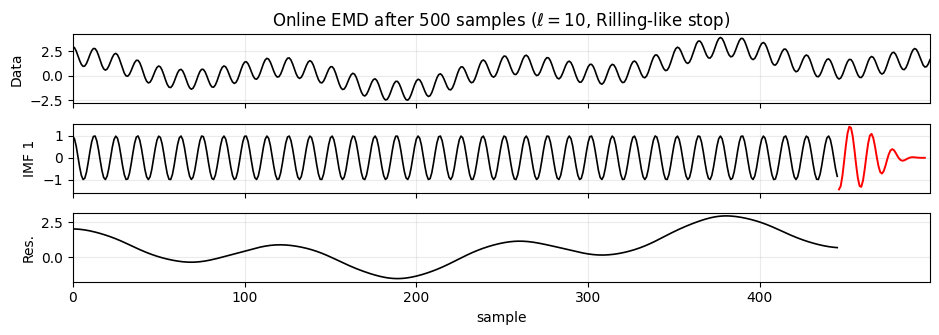

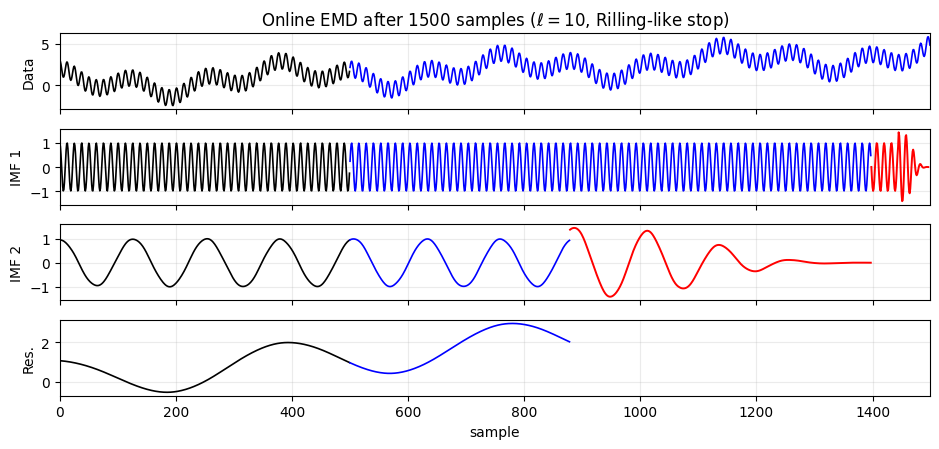

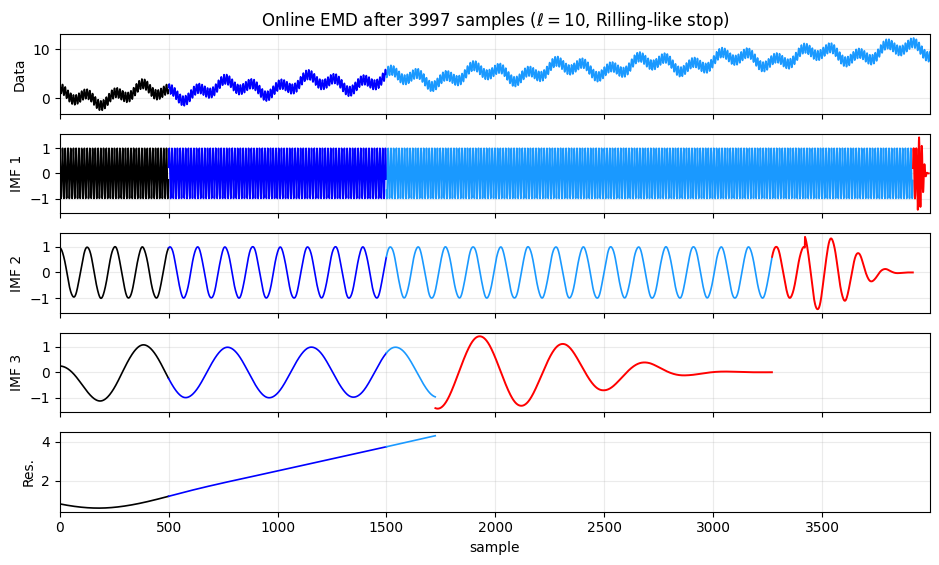

In [2]:
toy = fig2_signal(stop=2000.0, step=0.5)
x = toy["signal"]
print("N =", x.size, "samp[0] =", toy["samp"][0])

COLORS = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 1.0], [0.1, 0.6, 1.0]])


def _segments(n):
    if n > 1501:
        return [0, 500, 1500, n]
    if n > 500:
        return [0, 500, n]
    return [0, n]


def plot_oemd(oemd, title, incomplete=True, max_imfs=5):
    stages = oemd.stages
    signal = stages[0].data
    res_idx = residual_stage_index(stages)
    n_imf = min(res_idx, max_imfs)
    n_rows = n_imf + 2
    fig, axes = plt.subplots(n_rows, 1, figsize=(9.5, 1.15 * n_rows), sharex=True)
    if n_rows == 1:
        axes = [axes]

    def _paint(ax, y, n_plot=None):
        y = np.asarray(y, dtype=float)
        n_plot = y.size if n_plot is None else min(n_plot, y.size)
        seq = _segments(n_plot)
        for k in range(len(seq) - 1):
            a, b = seq[k], seq[k + 1]
            b = min(b, y.size)
            ax.plot(np.arange(a, b), y[a:b], color=COLORS[min(k, 2)], lw=1.2)
        return n_plot

    _paint(axes[0], signal)
    axes[0].set_ylabel("Data")
    axes[0].set_title(title)

    n_signal = signal.size
    for i in range(n_imf):
        ax = axes[i + 1]
        imf = stages[i].imf
        if i + 1 < len(stages) and i + 1 == res_idx:
            start_inc = stages[i + 1].data.size
        elif i + 1 < res_idx:
            start_inc = (
                stages[i + 1].imf.size
                if stages[i + 1].imf.size
                else stages[i + 1].data.size
            )
        else:
            start_inc = stages[min(i + 1, len(stages) - 1)].data.size
        _paint(ax, imf, n_plot=min(start_inc, imf.size) if start_inc else imf.size)
        if incomplete and imf.size > start_inc > 0:
            ax.plot(
                np.arange(start_inc, imf.size),
                imf[start_inc:],
                color="red",
                lw=1.4,
            )
        ax.set_ylabel(f"IMF {i + 1}")

    ax_r = axes[n_imf + 1]
    residual = stages[res_idx].data if res_idx < len(stages) else np.zeros(0)
    _paint(ax_r, residual)
    ax_r.set_ylabel("Res.")
    ax_r.set_xlim(0, n_signal - 1)
    ax_r.set_xlabel("sample")
    for ax in axes:
        ax.grid(True, alpha=0.25)
    fig.tight_layout()
    return fig


snapshots = [500, 1500, x.size]
figs = []
for n in snapshots:
    oemd = OnlineEMD(n_extrema=10, emd_algo=0)
    oemd.fit_transform(x[:n])
    n_imf = residual_stage_index(oemd.stages)
    print(
        f"N={n:4d}  stages={len(oemd.stages)}  IMFs={n_imf}  committed={oemd.committed_length()}"
    )
    figs.append(
        plot_oemd(oemd, f"Online EMD after {n} samples ($\\ell=10$, Rilling-like stop)")
    )
plt.show()

Black / blue / light-blue mark the prefixes of 500 and 1500 samples, as
in MATLAB `plotIMFs.m`.  **Red** is the incomplete stitching lag.  After
500 samples only the fastest sine is an IMF; at 1500 the second mode has
started to peel off the residual; on the full record the trend sits in
the last residual.


## 4. Difference versus classical EMD

On the same mixture, batch EMD sifts the whole span and returns every
mode at once. Online EMD's modes are **causal prefixes** of that
decomposition: they agree in the interior once the lag has passed, but
the tail of each IMF is still being averaged.  The reconstruction
identity is

$$
x[0:L) = \sum_k c_k[0:L) + r[0:L)
$$

only up to the length $L$ of the **last** residual (the slowest committed
prefix), not the full $N$.


Online EMD (4, 3997) committed residual length 1726
EMD       (4, 3997)
prefix recon max |error| 8.881784197001252e-16


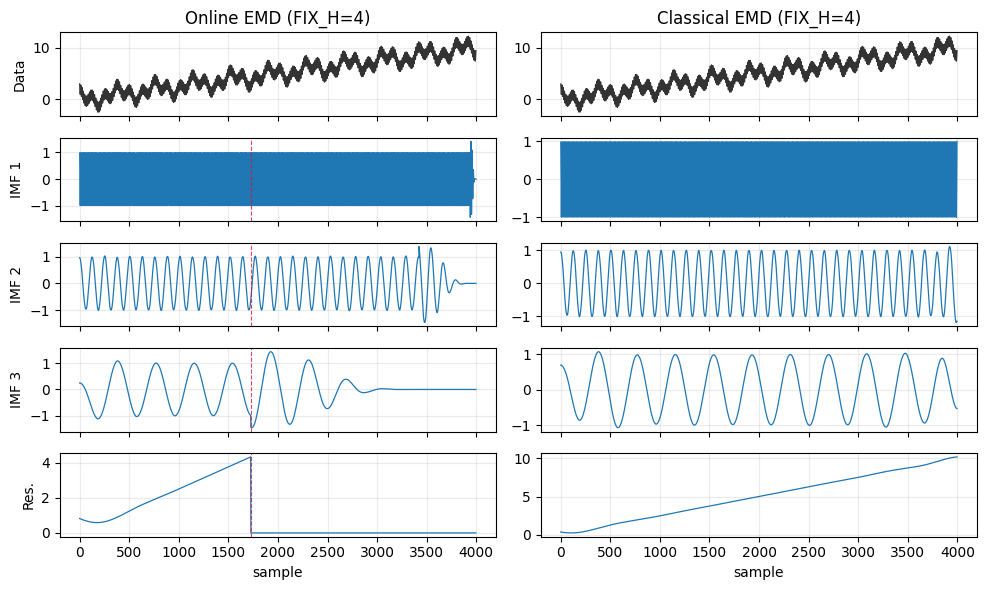

In [3]:
oemd = OnlineEMD(n_extrema=10, emd_algo=2)
imfs_on = oemd.fit_transform(x)
res_idx = residual_stage_index(oemd.stages)
L = oemd.stages[res_idx].data.size
recon = imfs_on[:, :L].sum(axis=0)

emd = EMD(max_imfs=3, FIXE_H=4)
imfs_off = emd.fit_transform(x, max_imfs=3)
print("Online EMD", imfs_on.shape, "committed residual length", L)
print("EMD      ", imfs_off.shape)
print("prefix recon max |error|", np.max(np.abs(recon - x[:L])))

n_show = min(4, imfs_on.shape[0], imfs_off.shape[0])
fig, axes = plt.subplots(n_show + 1, 2, figsize=(10, 1.2 * (n_show + 1)), sharex=True)
axes[0, 0].plot(x, color="0.2", lw=0.9)
axes[0, 0].set_title("Online EMD (FIX_H=4)")
axes[0, 0].set_ylabel("Data")
axes[0, 1].plot(x, color="0.2", lw=0.9)
axes[0, 1].set_title("Classical EMD (FIX_H=4)")
for k in range(n_show):
    axes[k + 1, 0].plot(imfs_on[k], lw=0.9)
    axes[k + 1, 1].plot(imfs_off[k], lw=0.9)
    label = (
        f"IMF {k + 1}"
        if k < n_show - 1 or imfs_on.shape[0] > n_show
        else ("Res." if k == imfs_on.shape[0] - 1 else f"IMF {k + 1}")
    )
    axes[k + 1, 0].set_ylabel(label)
    axes[k + 1, 0].axvline(L, color="crimson", ls="--", lw=0.8, alpha=0.8)
for ax in axes.ravel():
    ax.grid(True, alpha=0.25)
axes[-1, 0].set_xlabel("sample")
axes[-1, 1].set_xlabel("sample")
fig.tight_layout()
plt.show()

## 5. Streaming versus batch

`example_oemd_fig2.m` appends packets of 20 samples and calls `oemd_iter`
after each packet.  Dumping the same record at once (`fit_transform`)
must match the committed IMFs of that stream.


In [4]:
batch = OnlineEMD(n_extrema=10, emd_algo=2)
imf_batch = batch.fit_transform(x)

stream = OnlineEMD(n_extrema=10, emd_algo=2)
pkt = 20
for i in range(0, x.size, pkt):
    stream.update(x[i : i + pkt])
imf_stream = stream.get_imfs()

n_rows = min(imf_batch.shape[0], imf_stream.shape[0])
Lcmp = min(
    batch.stages[residual_stage_index(batch.stages)].data.size,
    stream.stages[residual_stage_index(stream.stages)].data.size,
)
err = np.max(np.abs(imf_batch[:n_rows, :Lcmp] - imf_stream[:n_rows, :Lcmp]))
print("packet size", pkt, "compared prefix", Lcmp, "max |batch-stream|", err)

packet size 20 compared prefix 1726 max |batch-stream| 0.0


## 6. ECG (paper Figure 5)

The MATLAB companion ships `data/ecg.mat` from MIT-BIH Normal Sinus
Rhythm (1280 samples, 128 Hz).  Figure 5 uses $\ell=10$ and a **fixed
10 siftings** (`emdAlgo=1`).  Spiky QRS complexes are a known mode-mixing
stress test; Online EMD is *not* as robust as EEMD here, but it does
separate a fast spike-like IMF from slower baseline wander without
re-reading the record.


ECG (1280,) fs 128.0 duration 9.9921875 s


Online Empirical Mode Decomposition (Online EMD) -> (7, 1280) stages 7


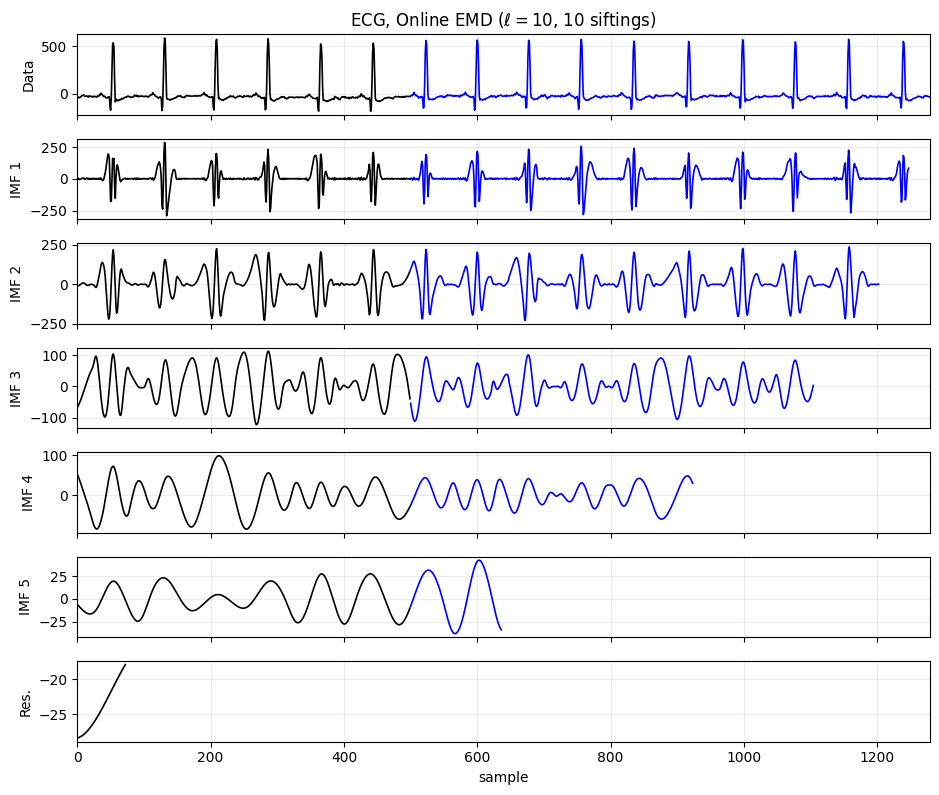

In [5]:
rec = load_oemd_ecg()
ecg, fs, t = rec["signal"], rec["fs"], rec["t"]
print("ECG", ecg.shape, "fs", fs, "duration", t[-1], "s")

oemd_ecg = OnlineEMD(n_extrema=10, emd_algo=1)
imfs_ecg = oemd_ecg.fit_transform(ecg)
print(oemd_ecg, "->", imfs_ecg.shape, "stages", len(oemd_ecg.stages))
plot_oemd(oemd_ecg, "ECG, Online EMD ($\\ell=10$, 10 siftings)", incomplete=False)
plt.show()

## 7. Window size and interior error

Paper Figure 3 reports MSE versus $\ell \in [10,30]$ on 5000 interior
samples of the long synthetic.  A short slice already shows the same
trend: very small windows are usable, and Online EMD stays close to
batch EMD in the interior once the lag is excluded.


EMD FIX_H interior MSE 0.0027010190288081137
Online EMD l= 8  MSE=0.001421
Online EMD l=10  MSE=0.000989
Online EMD l=12  MSE=0.001389
Online EMD l=14  MSE=3.580158


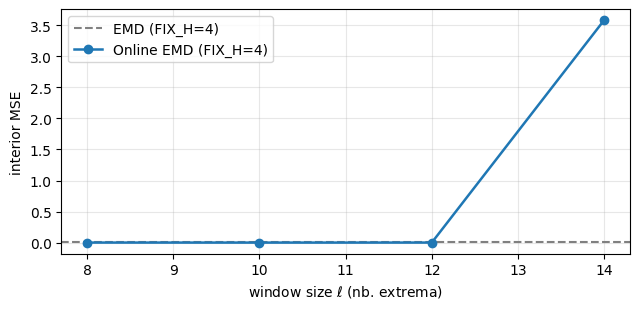

In [6]:
interior = slice(400, 1200)
ref = EMD(max_imfs=3, FIXE_H=4).fit_transform(x, max_imfs=3)
comp = [toy["comp1"], toy["comp2"], toy["comp3"], toy["trend"]]
n_ref = min(4, ref.shape[0])
mse_emd = sum(
    np.mean((comp[k][interior] - ref[k][interior]) ** 2) for k in range(n_ref)
)

ells = [8, 10, 12, 14]
mse_on = []
for ell in ells:
    on = OnlineEMD(n_extrema=ell, emd_algo=2).fit_transform(x)
    n_use = min(4, on.shape[0])
    mse_on.append(
        sum(np.mean((comp[k][interior] - on[k][interior]) ** 2) for k in range(n_use))
    )

print("EMD FIX_H interior MSE", mse_emd)
for ell, m in zip(ells, mse_on):
    print(f"Online EMD l={ell:2d}  MSE={m:.6f}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.axhline(mse_emd, color="0.5", ls="--", lw=1.5, label="EMD (FIX_H=4)")
ax.plot(ells, mse_on, "o-", color="C0", lw=1.8, label="Online EMD (FIX_H=4)")
ax.set_xlabel("window size $\\ell$ (nb. extrema)")
ax.set_ylabel("interior MSE")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Takeaway

Online EMD is still EMD **inside each window**.  The change is *when*
samples are committed and *how* overlapping local IMFs are averaged.
That is enough to follow a stream with almost constant work per packet
(paper Figure 4) while keeping the adaptive IMF count and stopping
rules that block-wise / weighted-sliding EMD give up.

```python
from pysdkit import OnlineEMD

oemd = OnlineEMD(n_extrema=10, emd_algo="fix_h")
imfs = oemd.fit_transform(signal)          # batch
oemd.reset()
imfs = oemd.update(new_packet)             # stream
```
